In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r'..\data\processed\df_preprocessed.csv')

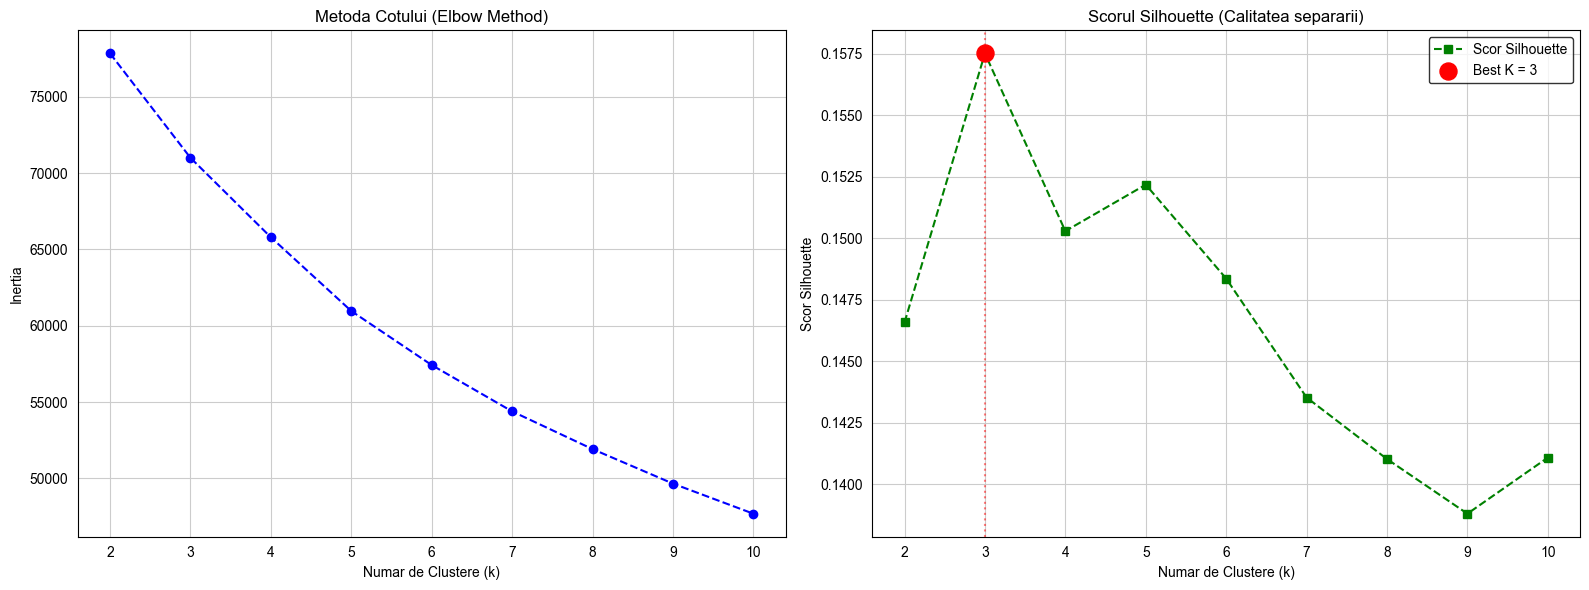

Cel mai bun numar de clustere este: 3 (scor: 0.1575)


<Figure size 640x480 with 0 Axes>

In [14]:
le = LabelEncoder()
analysis_encoded = df.copy()
categorical_features = ['segment', 'region', 'state', 'city', 'category', 'sub-category']
features = ['sales', 'discount', 'category', 'quantity', 'segment',
            'sub-category', 'state', 'city', 'region']
for col in categorical_features:
    analysis_encoded[col] = le.fit_transform(analysis_encoded[col].astype(str))

X = analysis_encoded[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_scaled, labels))

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'grid.color':        '#cccccc',
    'legend.facecolor':  'white',
    'legend.edgecolor':  'black',
    'legend.labelcolor': 'black',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# --- Elbow Method ---
ax1.plot(k_range, inertia, marker='o', color='b', linestyle='--')
ax1.set_title('Metoda Cotului (Elbow Method)', color='black')
ax1.set_xlabel('Numar de Clustere (k)', color='black')
ax1.set_ylabel('Inertia', color='black')
ax1.tick_params(colors='black')
ax1.grid(True, color='#cccccc')

# ---Silhouette ----
ax2.plot(k_range, silhouette_vals, marker='s', color='green', linestyle='--', label='Scor Silhouette')
best_index = np.argmax(silhouette_vals)
best_k_val = k_range[best_index]
best_score = silhouette_vals[best_index]
ax2.scatter(best_k_val, best_score, color='red', s=150, zorder=5, label=f'Best K = {best_k_val}')
ax2.axvline(x=best_k_val, color='red', linestyle=':', alpha=0.5)

ax2.set_title('Scorul Silhouette (Calitatea separarii)', color='black')
ax2.set_xlabel('Numar de Clustere (k)', color='black')
ax2.set_ylabel('Scor Silhouette', color='black')
ax2.tick_params(colors='black')
ax2.legend()
ax2.grid(True, color='#cccccc')

plt.tight_layout()
plt.show()

print(f"Cel mai bun numar de clustere este: {best_k_val} (scor: {best_score:.4f})")
plt.savefig('eda_graphs/eda_scorul_silhouette.png', dpi=150, bbox_inches='tight', facecolor='white')

C:\Users\Dan\AppData\Local\Temp\ipykernel_23768\1984044299.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


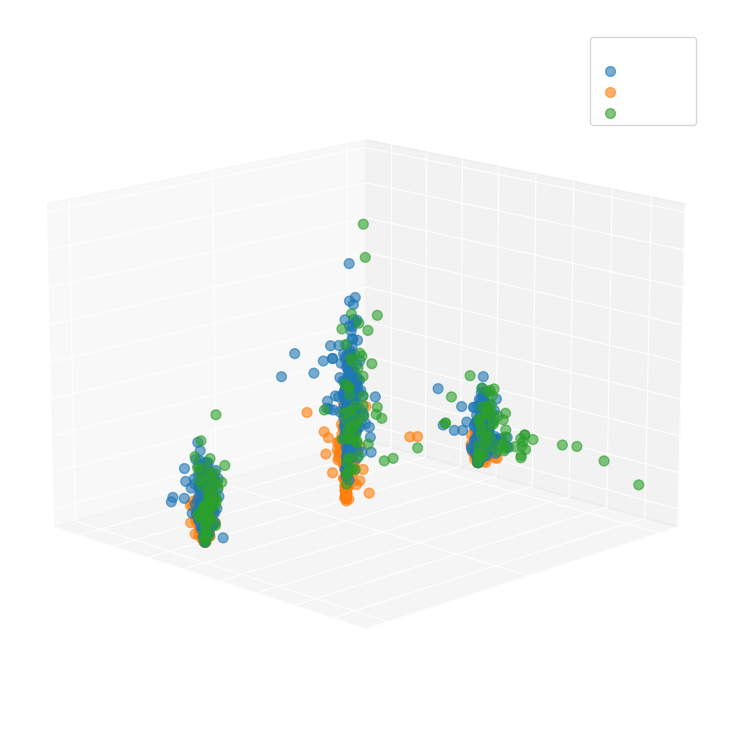

Statistici Profit per Categorie si Cluster:
category   Furniture  Office Supplies   Technology
cluster                                           
0          22.421113       172.648898   187.419134
1           4.355594        58.961394    53.932420
2         179.773447       776.625500  1257.781502


In [5]:
customer_cat_data = df.groupby(['customer_id', 'category']).agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum'
}).reset_index()

customer_summary = customer_cat_data.groupby('customer_id').agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum'
})

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_summary)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_summary['cluster'] = kmeans.fit_predict(scaled_features)

df_plot = customer_cat_data.merge(customer_summary[['cluster']], on='customer_id')

categories = sorted(df_plot['category'].unique())
cat_to_id = {cat: i for i, cat in enumerate(categories)}
df_plot['cat_id'] = df_plot['category'].map(cat_to_id)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(3):
    cluster_mask = df_plot['cluster'] == i
    ax.scatter(
        df_plot.loc[cluster_mask, 'profit'],
        df_plot.loc[cluster_mask, 'cat_id'],
        df_plot.loc[cluster_mask, 'quantity'],
        c=colors[i],
        label="Cluster " + str(i),
        s=50,
        alpha=0.6
    )

ax.set_xlabel('Profit')
ax.set_ylabel('Categorie (Y)')
ax.set_zlabel('Cantitate')

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.zaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.title('Vizualizare 3D: Profit (X), Category (Y) si Cantitate (Z)')
ax.legend(title="Clustere Clienti")

ax.view_init(elev=15, azim=-45)

plt.tight_layout()
plt.show()

print("Statistici Profit per Categorie si Cluster:")
print(df_plot.groupby(['cluster', 'category'])['profit'].mean().unstack())

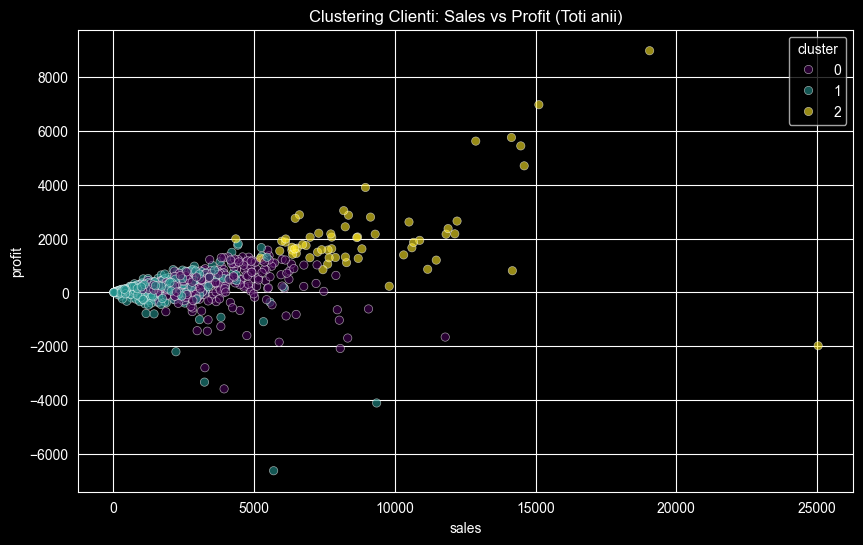

Media indicatorilor pe fiecare cluster:
               sales       profit   quantity  discount  shipping_delay  \
cluster                                                                  
0        3448.304132   299.079646  65.208861  0.163801        3.994443   
1        1550.187372   139.977473  30.411058  0.158532        3.916643   
2        9223.914884  2191.102044  75.672131  0.117584        3.972881   

         total_orders  
cluster                
0            8.329114  
1            4.487981  
2            8.360656  


In [5]:
customer_data = df.groupby('customer_id').agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'shipping_delay': 'mean',
    'order_id': 'nunique'
}).rename(columns={'order_id': 'total_orders'})

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_data['cluster'] = kmeans.fit_transform(scaled_features).argmin(axis=1) # Atribuim clusterul


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_data,
    x='sales',
    y='profit',
    hue='cluster',
    palette='viridis',
    alpha=0.6
)
plt.title('Clustering Clienti: Sales vs Profit (Toti anii)')
plt.show()


cluster_summary = customer_data.groupby('cluster').mean()
print("Media indicatorilor pe fiecare cluster:")
print(cluster_summary)

In [6]:
customer_monthly_data = df.groupby(['customer_id', 'order_month']).agg({
    'profit': 'sum',
    'quantity': 'sum',
    'sales': 'sum'
}).reset_index()

features = customer_monthly_data[['profit', 'quantity', 'order_month']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_monthly_data['cluster'] = kmeans.fit_predict(scaled_features).astype(str)

fig = px.scatter_3d(
    customer_monthly_data,
    x='sales',
    y='quantity',
    z='order_month',
    color='cluster',
    opacity=0.7,
    title='Clustering 3D: Vanzari, Cantitate si Luna (3 Clustere)',
    labels={
        'sales': 'Vanzari',
        'quantity': 'Cantitate',
        'order_month': 'Luna'
    },
    hover_data=['customer_id']
)

fig.update_layout(
    scene=dict(
        xaxis_title='Vanzari (X)',
        yaxis_title='Cantitate (Y)',
        zaxis_title='Luna (Z)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

print("Media indicatorilor pe cele 3 clustere:")
print(customer_monthly_data.groupby('cluster')[['sales', 'quantity', 'order_month']].mean())

Media indicatorilor pe cele 3 clustere:
               sales   quantity  order_month
cluster                                     
0        1876.806978  25.783784     8.812613
1         402.715268   7.315889     4.296343
2         383.862210   7.442439    10.154325


In [7]:
stats_subcat = df.groupby(['region', 'sub-category']).agg({
    'sales': 'sum',
    'profit': 'sum',
    'quantity': 'sum'
}).reset_index()

features = stats_subcat[['sales', 'profit', 'quantity']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
stats_subcat['cluster'] = kmeans.fit_predict(scaled_features).astype(str)

fig = px.scatter_3d(
    stats_subcat,
    x='sales',
    y='region',
    z='sub-category',
    color='cluster',
    size='quantity',
    hover_data=['profit'],
    title='Clustering 3D: Vanzari (X), Regiune (Y) si Sub-category (Z)',
    labels={
        'sales': 'Vanzari Total',
        'region': 'Regiune (Area)',
        'sub-category': 'Sub-category'
    },
    opacity=0.8,
    height=800
)

fig.update_layout(
    scene=dict(
        xaxis_title='Vanzari',
        yaxis_title='Regiune',
        zaxis_title='Sub-category'
    ),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

print("Media indicatorilor pe clustere pentru Sub-category:")
print(stats_subcat.groupby('cluster')[['sales', 'profit', 'quantity']].mean())


Media indicatorilor pe clustere pentru Sub-category:
                sales        profit     quantity
cluster                                         
0        17318.250869    -24.310086   311.611111
1        84298.938700   8872.843130   824.700000
2        43682.393364  10761.058764   376.363636
3        31840.737727   7288.373373  1297.090909


In [8]:
customer_monthly_data = df.groupby(['customer_id', 'order_month']).agg({
    'discount': 'sum',
    'quantity': 'sum',
    'sales': 'sum',
    'sub-category': 'first',
    'segment': 'first',
}).reset_index()

le = LabelEncoder()
customer_monthly_data['sub-category-enc'] = le.fit_transform(customer_monthly_data['segment'].astype(str))

features_list = ['sales', 'quantity', 'order_month']
X = customer_monthly_data[features_list]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
customer_monthly_data['cluster'] = kmeans.fit_predict(scaled_features).astype(str)

fig = px.scatter_3d(
    customer_monthly_data,
    x='sales',
    y='quantity', # Folosim quantity pe Y pentru vizualizare, chiar daca nu e in clustering
    z='order_month',
    color='cluster',
    opacity=0.7,
    title=f'Clustering 3D: Vanzari, Cantitate si Luna ({n_clusters} Clustere)',
    labels={
        'sales': 'Vanzari',
        'quantity': 'Cantitate',
        'order_month': 'Luna'
    },
    hover_data=['customer_id', 'sub-category']
)

fig.update_layout(
    scene=dict(
        xaxis_title='Vanzari (X)',
        yaxis_title='Cantitate (Y)',
        zaxis_title='Luna (Z)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

print(f"Media indicatorilor pe cele {n_clusters} clustere:")
print(customer_monthly_data.groupby('cluster')[['sales', 'quantity', 'order_month']].mean())

Media indicatorilor pe cele 5 clustere:
                sales   quantity  order_month
cluster                                      
0          257.823872   5.890268     9.703462
1          930.931889  18.640483     9.506042
2        11333.766625  20.250000     7.625000
3          344.274148   7.159817     3.802131
4         2899.907132  30.146667     7.804444


In [9]:

# 1. Agregarea datelor (trebuie sa includem 'profit' aici)
customer_monthly_data = df.groupby(['customer_id', 'order_month']).agg({
    'discount': 'mean',     # Folosim media pentru discount per comanda
    'quantity': 'sum',
    'sales': 'sum',
    'profit': 'sum',        # Am adaugat profitul
    'sub-category': 'first',
    'segment': 'first',
}).reset_index()

# 2. Pregatirea datelor pentru Clustering
# Am schimbat lista conform cerintei tale: sales, profit, discount
features_list = ['sales', 'profit', 'discount']
X = customer_monthly_data[features_list]

# Scalarea este esentiala pentru K-Means
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Aplicarea K-Means (5 clustere)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
customer_monthly_data['cluster'] = kmeans.fit_predict(scaled_features).astype(str)

# 4. Vizualizare 3D folosind noile dimensiuni
fig = px.scatter_3d(
    customer_monthly_data,
    x='sales',
    y='profit',      # Axa Y este acum Profit
    z='discount',    # Axa Z este acum Discount
    color='cluster',
    opacity=0.7,
    title=f'Clustering 3D: Vanzari, Profit si Discount ({n_clusters} Clustere)',
    labels={
        'sales': 'Vanzari ($)',
        'profit': 'Profit ($)',
        'discount': 'Discount (%)'
    },
    hover_data=['customer_id', 'sub-category', 'quantity']
)

fig.update_layout(
    scene=dict(
        xaxis_title='Vanzari (X)',
        yaxis_title='Profit (Y)',
        zaxis_title='Discount (Z)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# 5. Afisarea mediilor pentru interpretarea clusterelor
print(f"Interpretarea clusterelor (Media indicatorilor):")
analysis = customer_monthly_data.groupby('cluster')[features_list].mean().sort_values(by='profit', ascending=False)
print(analysis)

Interpretarea clusterelor (Media indicatorilor):
               sales       profit  discount
cluster                                    
2        4520.760223  1100.053320  0.074695
0         429.611657    75.907615  0.091207
1         550.212814  -145.509964  0.455915
